## NoteBook by
### - Himel Sarder

In [3]:
import numpy as np
import pandas as pd

In [17]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [5]:
df = pd.read_csv('car_sales.csv')

In [6]:
df.sample(10)

,Age (Years),Mileage (Km),Engine_Size (L),Target
517,20,207360.482115,1.877096,0
1074,16,281519.221794,2.133219,0
292,15,118165.616820,1.555485,0
337,12,240055.359220,4.786578,0
275,16,227341.156045,2.026777,0
983,11,264545.863353,3.191139,0
830,5,160023.863481,4.306987,0
726,1,117845.252672,2.567433,1
1038,8,115171.465863,3.659978,0
997,5,226115.917918,1.575768,0


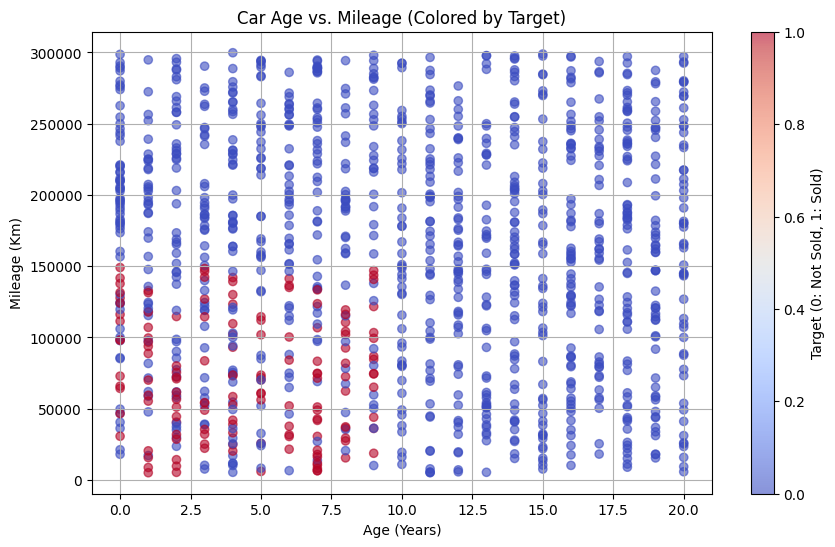

In [7]:
# Scatter plot for Age vs. Mileage colored by Target
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["Age (Years)"], df["Mileage (Km)"], c=df["Target"], cmap="coolwarm", alpha=0.6)
plt.colorbar(scatter, label="Target (0: Not Sold, 1: Sold)")
plt.xlabel("Age (Years)")
plt.ylabel("Mileage (Km)")
plt.title("Car Age vs. Mileage (Colored by Target)")
plt.grid(True)
plt.show()

In [8]:
X = df.drop(columns=['Target'])
y = df['Target']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
X_train.head()

,Age (Years),Mileage (Km),Engine_Size (L)
409,15,134389.128864,4.410231
100,6,271492.324728,1.765042
168,19,120530.891459,4.298139
575,5,101872.462226,2.016926
750,20,87512.543849,4.092356


In [11]:
# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Without binarization

# Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

In [13]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f"Model Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Model Accuracy: 0.8913

Confusion Matrix:
 [[188   2]
 [ 23  17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94       190
           1       0.89      0.42      0.58        40

    accuracy                           0.89       230
   macro avg       0.89      0.71      0.76       230
weighted avg       0.89      0.89      0.87       230



In [14]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

# Print results
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.92391304 0.86413043 0.88043478 0.88586957 0.89673913]
Mean Accuracy: 0.8902
Standard Deviation: 0.0199


In [18]:
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Random Forest Mean Accuracy: {cv_scores_rf.mean():.4f}")

Random Forest Mean Accuracy: 0.9978


In [19]:
# Applying Binarization

from sklearn.preprocessing import Binarizer

In [20]:
trf = ColumnTransformer([
    ('age_bin', Binarizer(threshold=14.0, copy=False), [0]),  # Age > 5 gets 1, otherwise 0
    ('engine_bin', Binarizer(threshold=2.5, copy=False), [2]),  # Engine Size > 2.0 gets 1, otherwise 0
    ('mileage_scale', StandardScaler(), [1])  # Standardizing Mileage
], remainder='passthrough')

In [21]:
trf

ColumnTransformer(remainder='passthrough',
                  transformers=[('age_bin',
                                 Binarizer(copy=False, threshold=14.0), [0]),
                                ('engine_bin',
                                 Binarizer(copy=False, threshold=2.5), [2]),
                                ('mileage_scale', StandardScaler(), [1])])

In [23]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [24]:
df1 = pd.DataFrame(X_train_trf, columns=['Age_Bin', 'Engine_Size_bin', 'Mileage (Km)_scale'])

df1.head(10)

,Age_Bin,Engine_Size_bin,Mileage (Km)_scale
0,1.0,1.0,-0.204076
1,0.0,0.0,1.410037
2,1.0,1.0,-0.367228
3,0.0,0.0,-0.586894
4,1.0,1.0,-0.755953
5,0.0,1.0,1.680491
6,1.0,1.0,0.885832
7,0.0,0.0,1.691310
8,0.0,1.0,1.211663
9,0.0,1.0,1.612522


In [25]:
# Train the Logistic Regression model
model1 = LogisticRegression()
model1.fit(X_train_trf, y_train)

# Make predictions
y_pred1 = model1.predict(X_test_trf)

In [26]:
accuracy = accuracy_score(y_test, y_pred1)
conf_matrix = confusion_matrix(y_test, y_pred1)
class_report = classification_report(y_test, y_pred1)

# Print results
print(f"Model Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Model Accuracy: 0.8391

Confusion Matrix:
 [[189   1]
 [ 36   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.99      0.91       190
           1       0.80      0.10      0.18        40

    accuracy                           0.84       230
   macro avg       0.82      0.55      0.54       230
weighted avg       0.83      0.84      0.78       230



In [277]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X_train_trf, y_train, cv=5, scoring='accuracy')

# Print results
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.89673913 0.85869565 0.88586957 0.88043478 0.88586957]
Mean Accuracy: 0.8815
Standard Deviation: 0.0126


In [16]:
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X_train_trf, y_train, cv=5, scoring='accuracy')

print(f"Random Forest Mean Accuracy: {cv_scores_rf.mean():.4f}")

NameError: name 'RandomForestClassifier' is not defined